In [1]:
import arviz as az
import os.path as op
import pymc as pm

from risk_experiment.cogmodels.fit_model import build_model, get_data

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

/Users/gdehol/mambaforge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_info(model_label, session=None, bids_folder='/data/ds-risk'):

    df = get_data(model_label, session, bids_folder, None)
    model = build_model(model_label, df, None)

    model.build_estimation_model()

    idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

    if 'log_likelihood' not in idata:
        with model.estimation_model:
            pm.compute_log_likelihood(idata)

    return df, model, idata



In [3]:
models_labels = [('klw', 'Model A: Shared prior, equal noise'),
          ('12', 'PMRC model',),
          ('42', 'Model C: Shared prior, varying noise'),
          ('52', 'Model B: Varying priors, equal noise'),
          ('eu', 'Model D: Expected utility model')]

models = {}

for model_label, model_name in tqdm(models_labels):
    df, model, idata = get_info(model_label)
    models[model_name] = idata

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
comparison = az.compare(models)

/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:805: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:805: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/

/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/plots/backends/matplotlib/compareplot.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = comp_df["scale"][0]


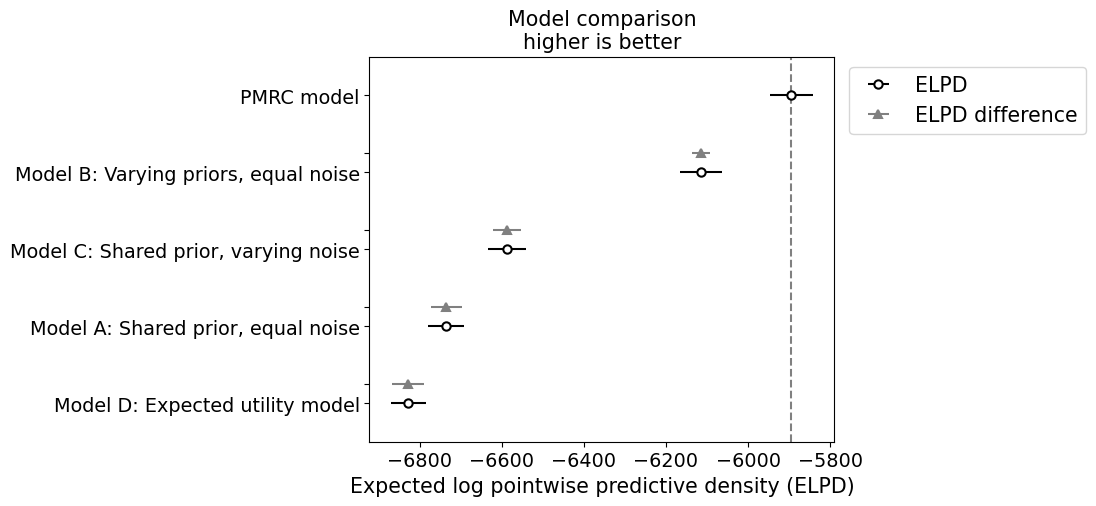

In [ ]:
az.plot_compare(comparison)

plt.ylabel(None)

plt.xlabel('Expected log pointwise predictive density (ELPD)')

plt.savefig('/data/ds-risk/derivatives/figures/model_comparison.pdf', bbox_inches='tight')